# Milestone 2 — the lake mask: what it changed

Section 10 of `m2_hex_table.ipynb` found that 25 of the top 40 hexes were lake hexes, 6.5 times the
city-wide rate, because rule C missed lakes that sit under weed or are dry for part of the run.
Decided on 2026-09-23:

1. **Mask mapped water at the pixel level.** Every pixel inside an OSM lake, pond, reservoir or
   sewage pond is dropped before a hex is averaged, the same pixels in every year
   (`measure_hexes.py --mask-water` → `results/m2_hex_table_masked.csv`). **Wetlands are kept**:
   their loss belongs in the story, and OSM maps them too patchily to mask consistently.
2. **Rule C is dropped.** The masked table is read with no hex-level water exclusion. One approach,
   not two.
3. **No minimum-land cutoff yet.** Section 5 only *measures* what a 25% cutoff would change, so the
   decision can be made from numbers.

The ranking is the same as section 10's: the 40 largest changes by **end-minus-start**, meaning
normalised 2026 minus normalised 2019, losses and gains both counted.

**No Earth Engine.** It reads the two hex tables, `results/m2_water_hexes.csv` (only to compare
against the old list), `data/hex_grid.geojson` and `data/osm_water.geojson`.

In [1]:
import os
from pathlib import Path

import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)

METRIC = "EPSG:32643"
INK, MUTED, LOSS, GAIN = "#2b2b2b", "#8a8a8a", "#8c2d04", "#1b7837"
LAKE_CUTOFF = 0.10
LAND_CUTOFF = 0.25
TOP = 40

old = pd.read_csv("results/m2_hex_table.csv")
new = pd.read_csv("results/m2_hex_table_masked.csv")
rule_c = set(pd.read_csv("results/m2_water_hexes.csv").h3)
grid = gpd.read_file("data/hex_grid.geojson").to_crs(METRIC).set_index("h3")
osm = gpd.read_file("data/osm_water.geojson").to_crs(METRIC)

assert len(new) == len(old), f"masked table incomplete: {len(new):,} of {len(old):,} rows"

full_px = old.groupby("h3").n_pixels.median()
land = (new.groupby("h3").n_pixels.median() / full_px).rename("land")


def normalised(table, drop=()):
    g = table[~table.h3.isin(drop)].pivot(index="h3", columns="year", values="green").dropna()
    return g, g.sub(g.mean(axis=0), axis=1)


g_old, n_old = normalised(old, drop=rule_c)
g_new, n_new = normalised(new)
YEARS = list(g_new.columns)
ems_old = n_old[YEARS[-1]] - n_old[YEARS[0]]
ems_new = n_new[YEARS[-1]] - n_new[YEARS[0]]
rank_old = ems_old.abs().rank(ascending=False).astype(int)
rank_new = ems_new.abs().rank(ascending=False).astype(int)
top_old = ems_old.abs().nlargest(TOP).index
top_new = ems_new.abs().nlargest(TOP).index


def share_of(frame):
    pieces = gpd.overlay(grid.reset_index()[["h3", "geometry"]], frame[["geometry"]])
    return (pieces.dissolve(by="h3").area / grid.geometry.area).reindex(grid.index).fillna(0)


masked_share = share_of(osm[osm["class"] != "wetland"])
wetland_share = share_of(osm[osm["class"] == "wetland"])
any_share = share_of(osm)
named = (gpd.overlay(grid.reset_index()[["h3", "geometry"]], osm[["name", "geometry"]])
         .assign(area=lambda f: f.area).sort_values("area", ascending=False)
         .groupby("h3").name.apply(lambda s: next((n for n in s if n), "")))

print(f"old: {len(g_old):,} hexes (rule C removed {len(rule_c)})   new: {len(g_new):,} hexes "
      f"({len(grid) - len(g_new)} are all water, no land left)")

old: 2,818 hexes (rule C removed 50)   new: 2,868 hexes (0 are all water, no land left)


---
## 1 — What the mask removed

How much land each hex has left once mapped water is taken out. Most hexes lose nothing. The ones
that lose a lot are the lake hexes, which now count only their land part.

In [2]:
brackets = pd.cut(land, [-0.001, 0.05, 0.10, 0.25, 0.50, 0.90, 0.999, 1.001],
                  labels=["<5%", "5-10%", "10-25%", "25-50%", "50-90%", "90-99.9%", "untouched"])
print(brackets.value_counts().reindex(brackets.cat.categories).rename("hexes").to_string())
masked_km2 = ((1 - land) * grid.geometry.area).sum() / 1e6
print(f"\nland pixels removed: {masked_km2:.1f} km2 of {grid.geometry.area.sum() / 1e6:,.0f} km2")
print(f"rule C's {len(rule_c)} hexes: median land left {land[list(rule_c)].median():.0%}; "
      f"{(land[list(rule_c)] > 0.9).sum()} of them keep over 90% of their land "
      f"(water the satellite saw that OSM doesn't map)")

<5%             2
5-10%           1
10-25%          5
25-50%         21
50-90%        230
90-99.9%     1034
untouched    1575

land pixels removed: 74.2 km2 of 2,173 km2
rule C's 50 hexes: median land left 56%; 4 of them keep over 90% of their land (water the satellite saw that OSM doesn't map)


---
## 2 — Before and after, at the top of the ranking

The question section 10 asked, asked again. A *lake hex* is still a hex with at least 10% mapped
water in it. After the mask that water isn't measured, only the land around it, so a lake hex at the
top now means the land *beside* a lake changed, not the lake itself. The wetland line counts the one
kind of water that was deliberately left in.

In [3]:
def lake_rate(idx):
    return (any_share[idx] >= LAKE_CUTOFF).mean()


rows = {
    "all hexes": (lake_rate(g_new.index), (wetland_share[g_new.index] >= LAKE_CUTOFF).mean()),
    f"top {TOP} before the mask": (lake_rate(top_old), (wetland_share[top_old] >= LAKE_CUTOFF).mean()),
    f"top {TOP} after the mask": (lake_rate(top_new), (wetland_share[top_new] >= LAKE_CUTOFF).mean()),
}
summary = pd.DataFrame(rows, index=["lake hexes (any mapped water >= 10%)", "wetland >= 10%"]).T
print(summary.map("{:.1%}".format).to_string())
print(f"\nhexes in both top-{TOP} lists: {len(set(top_old) & set(top_new))} of {TOP}")
print(f"end-minus-start, before vs after, correlation over all hexes: "
      f"{ems_old.corr(ems_new.reindex(ems_old.index)):+.3f}")

                       lake hexes (any mapped water >= 10%) wetland >= 10%
all hexes                                             11.1%           1.8%
top 40 before the mask                                62.5%          17.5%
top 40 after the mask                                 47.5%          25.0%

hexes in both top-40 lists: 25 of 40
end-minus-start, before vs after, correlation over all hexes: +0.889


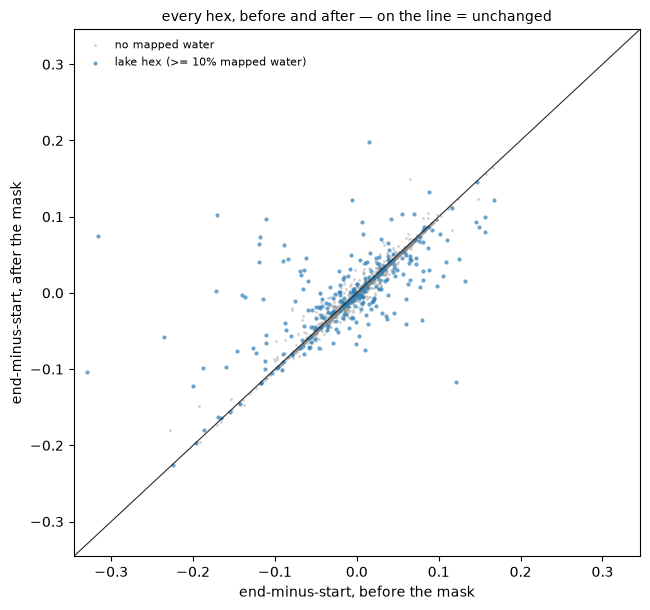

In [4]:
common = ems_old.index.intersection(ems_new.index)
fig, ax = plt.subplots(figsize=(6.6, 6.2))
lake = any_share[common] >= LAKE_CUTOFF
ax.scatter(ems_old[common][~lake], ems_new[common][~lake], s=4, color=MUTED, alpha=0.4, linewidths=0,
           label="no mapped water")
ax.scatter(ems_old[common][lake], ems_new[common][lake], s=9, color="#2c7fb8", alpha=0.7, linewidths=0,
           label=f"lake hex (>= {LAKE_CUTOFF:.0%} mapped water)")
lim = max(ems_old.abs().max(), ems_new.abs().max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], color=INK, linewidth=0.8)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("end-minus-start, before the mask")
ax.set_ylabel("end-minus-start, after the mask")
ax.set_title("every hex, before and after — on the line = unchanged", fontsize=10)
ax.legend(fontsize=8, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

---
## 3 — The new top 40

`old rank` is the hex's position before the mask (`-` if rule C had removed it). `land` is the share of
the hex still measured. `water nearby` is the largest named water body OSM maps in it.

In [5]:
top_table = pd.DataFrame({
    "rank": range(1, TOP + 1),
    "change": ems_new[top_new].round(3),
    "old rank": [str(rank_old[h]) if h in rank_old.index else "-" for h in top_new],
    "land": land[top_new].map("{:.0%}".format),
    "masked water": masked_share[top_new].map("{:.0%}".format),
    "wetland": wetland_share[top_new].map("{:.0%}".format),
    "water nearby": named.reindex(top_new).fillna(""),
}, index=top_new)
print(top_table.to_string())

print("\nsatellite view, top 10:")
for h in top_new[:10]:
    lat, lng = h3.cell_to_latlng(h)
    print(f"  {rank_new[h]:2d}  {h}  {ems_new[h]:+.3f}  https://www.google.com/maps/@{lat:.5f},{lng:.5f},16z/data=!3m1!1e3")

                 rank  change old rank  land masked water wetland         water nearby
h3                                                                                    
8861893493fffff     1   0.312        -   32%          69%     20%       Hennagara Lake
88618921a3fffff     2  -0.226        5  100%           0%     15%                     
8861892c69fffff     3  -0.221        -   56%          45%     16%        Ramapura Kere
88601694a5fffff     4   0.198     1793   32%          68%      0%    Hesaraghatta Lake
88618921b5fffff     5  -0.198        7  100%           0%     13%                     
8860169685fffff     6  -0.195        9   92%           8%      0%   Medi Agrahara Lake
8860169481fffff     7   0.181        -    0%         100%      0%    Hesaraghatta Lake
8861892c61fffff     8  -0.180        4   90%           9%      3%        Ramapura Kere
886016968bfffff     9  -0.180       11   86%          15%      0%   Ganigarahalli Lake
8860169681fffff    10  -0.173       13  100

---
## 4 — Where the familiar hexes went

The three from the deep dive, plus rank 2 from before (99% Hesaraghatta Lake).

In [6]:
familiar = {
    "A  Attur Lake, lake refilling": "8860169631fffff",
    "B  Shivaram Karanth Layout, field cleared": "88601696e3fffff",
    "C  Bellandur Lake + sewage plant": "8861892501fffff",
    "   Hesaraghatta Lake, 99% water": "88601694a1fffff",
}
for label, h in familiar.items():
    before = f"{ems_old[h]:+.3f} rank {rank_old[h]:4d}" if h in ems_old.index else "removed by rule C"
    after = f"{ems_new[h]:+.3f} rank {rank_new[h]:4d}" if h in ems_new.index else "no land left"
    print(f"{label:<44} land {land[h]:4.0%}   before {before:<22}  after {after}")

A  Attur Lake, lake refilling                land  86%   before -0.160 rank   20        after -0.097 rank   83
B  Shivaram Karanth Layout, field cleared    land  95%   before -0.110 rank   72        after -0.112 rank   51
C  Bellandur Lake + sewage plant             land  46%   before -0.188 rank   10        after -0.099 rank   72
   Hesaraghatta Lake, 99% water              land   1%   before -0.316 rank    2        after +0.074 rank  194


---
## 5 — What a 25% minimum-land cutoff would change (measured, not applied)

A hex with little land left gets the same place in the ranking as a whole hex, though its change
covers much less ground. This counts how many of the new top 40 sit under 25% land, and which hexes
would move up into the list if they were removed.

In [7]:
small = land[top_new] < LAND_CUTOFF
print(f"top {TOP} hexes with under {LAND_CUTOFF:.0%} land left: {small.sum()}")
if small.any():
    print(top_table[small.values][["rank", "change", "land", "water nearby"]].to_string())
eligible = ems_new[land.reindex(ems_new.index) >= LAND_CUTOFF].abs().nlargest(TOP).index
print(f"\nwith the cutoff, {len(set(eligible) - set(top_new))} hexes would move into the top {TOP}; "
      f"{len(set(top_new) & set(eligible))} stay")

top 40 hexes with under 25% land left: 2
                 rank  change land       water nearby
h3                                                   
8860169481fffff     7   0.181   0%  Hesaraghatta Lake
8861892509fffff    12  -0.165  10%     Bellandur Lake

with the cutoff, 2 hexes would move into the top 40; 38 stay


---
## What this shows

**The mask did what it was meant to, and hexes with no water didn't move.** In the scatter every
hex without mapped water sits on the line. Only lake hexes moved, and they moved a lot.

**Lakes no longer dominate the top 40, but they haven't gone.**

| | lake hexes in the top 40 | wetland ≥10% in the top 40 |
|---|---|---|
| city-wide rate | 11.1% | 1.8% |
| before the mask | 25 (62.5%) | 7 (17.5%) |
| after the mask | 19 (47.5%) | 10 (25%) |

About 21 of the new top 40 have no meaningful water nearby, against about 15 before. 15 of the 40 are
new to the list.

**The familiar hexes behave the way the photos said they should:**
- **A (Attur Lake):** rank 20 → 83. With the refilling lake masked, what's left is its real clearing
  (−0.097).
- **B (the field cleared for a layout):** rank 72 → 51. It moved *up*, which is the point of the exercise.
- **C (Bellandur edge):** rank 10 → 72.
- **The hex that is 99% Hesaraghatta:** rank 2 → 194. Only 98 pixels of land are left in it.

**What's still at the top, and why it needs a look before anyone trusts it:**

1. **Hexes rule C used to remove outright now enter through their land part.** Rank 1 (Hennagara
   Lake, 32% land, +0.312), rank 3 (Ramapura, 56%), rank 4 (Hesaraghatta, 32%, old rank 1793), rank 7
   (Hesaraghatta, about 0% land) and rank 12 (Bellandur, 10% land). Their "land" is a ring round a
   lake. If the real water edge sits outside the mapped outline in some years, or the mapped outline
   is smaller than the lake bed, that ring is still lake margin. **Shoreline is the leftover
   problem.**
2. **Wetlands are now 14 times their city-wide rate at the top** (10 of 40 against 1.8%). That's
   expected, since they were kept on purpose. Whether each is a wetland being filled or marsh
   flipping between weed and water is exactly what the photos can tell apart. Ranks 2 and 5 are
   unnamed wetlands side by side near Whitefield (13.015, 77.74).

**The 25% cutoff (measured, not applied):** only **2** of the top 40 fall under it. Rank 7 has almost no
land left and rank 12 has 10%. Applying it swaps 2 hexes and leaves 38. Rank 7 is the sliver case the
cutoff was proposed for.

**Next:** the same photo check as the deep dive, on the new top 10 or so, before reading any of these
as findings.

---
## 6 — The ranking, with the cutoff applied and a review flag

Decided 2026-09-23 after the photo check (`m2_top_photo_check.ipynb`):

- **Cutoff:** a hex with under **25%** land left after masking is not ranked. Its change describes
  too little ground to stand beside a whole hex. The photo check found exactly two of these in the
  top 12 (the Hesaraghatta and Bellandur slivers).
- **Review flag, not an exclusion:** wetland is still measured. But lake-side wetland is sometimes
  really part of the lake, so each hex also shows **clean land**: the share of the hex that is
  neither masked water *nor* wetland. Where clean land is under **90%** (the same 10% line used for
  lake hexes throughout), the hex is flagged `check`. Its number may be lake behaviour rather than
  land change, and it should be looked at before it's quoted.

The normalisation is unchanged, still over every hex. The cutoff only decides which hexes may be
ranked.

In [8]:
CLEAN_CUTOFF = 0.90

clean_land = 1 - any_share
ranked = ems_new[land.reindex(ems_new.index) >= LAND_CUTOFF]
top_final = ranked.abs().nlargest(TOP).index

final = pd.DataFrame({
    "rank": range(1, TOP + 1),
    "change": ranked[top_final].round(3),
    "direction": ["loss" if c < 0 else "gain" for c in ranked[top_final]],
    "land": land[top_final].map("{:.0%}".format),
    "clean land": clean_land[top_final].map("{:.0%}".format),
    "review": ["check" if c < CLEAN_CUTOFF else "" for c in clean_land[top_final]],
    "water nearby": named.reindex(top_final).fillna(""),
}, index=top_final)

print(f"ranked: {len(ranked):,} hexes ({len(ems_new) - len(ranked)} under {LAND_CUTOFF:.0%} land dropped: "
      f"{', '.join(ems_new.index.difference(ranked.index))})")
print(f"top {TOP}: {(final.review == 'check').sum()} flagged for review "
      f"(clean land under {CLEAN_CUTOFF:.0%}), {(final.review == '').sum()} clean\n")
print(final.to_string())

ranked: 2,860 hexes (8 under 25% land dropped: 8860169481fffff, 8860169485fffff, 88601694a1fffff, 88618920e1fffff, 886189221bfffff, 8861892509fffff, 88618928cbfffff, 8861892ab5fffff)
top 40: 18 flagged for review (clean land under 90%), 22 clean

                 rank  change direction  land clean land review         water nearby
h3                                                                                  
8861893493fffff     1   0.312      gain   32%        11%  check       Hennagara Lake
88618921a3fffff     2  -0.226      loss  100%        85%  check                     
8861892c69fffff     3  -0.221      loss   56%        39%  check        Ramapura Kere
88601694a5fffff     4   0.198      gain   32%        32%  check    Hesaraghatta Lake
88618921b5fffff     5  -0.198      loss  100%        87%  check                     
8860169685fffff     6  -0.195      loss   92%        92%          Medi Agrahara Lake
8861892c61fffff     7  -0.180      loss   90%        91%               Ra

**The cutoff removes 8 hexes from the ranking**, including both slivers the photo check found:
Hesaraghatta `8860169481fffff` (former rank 7) and Bellandur `8861892509fffff` (former rank 12). The
99%-Hesaraghatta hex `88601694a1fffff` is among the 8 as well. Everything below them moves up by up to
two places.

**18 of the top 40 are flagged `check`, and 22 are clean.** Read against the photo check of the top
ten:

| the flag says | photo check verdict |
|---|---|
| `check`: ranks 1, 3, 4 | artefact (Hennagara), lake works (Ramapura), crop swings (Hesaraghatta farm plots) |
| `check`: ranks 2, 5, 8 | **real losses**: wetland and fields built over east of Whitefield; layout clearing at Ganigarahalli |
| clean: ranks 6, 7, 9, 10 | **real losses**: Shivaram Karanth Layout, Ramapura north, east of Whitefield |

So in the ten that were checked, the flag catches every doubtful hex and doesn't clear anything it
shouldn't. It also flags three real losses, because wetland being built over looks exactly like
wetland that is really lake. That is why it is a flag for case-by-case review and not an exclusion.

(`clean land` can read a point above `land`, e.g. 91% against 90%. `land` is counted in 10 m pixels
by Earth Engine, `clean land` is polygon area; the two agree to about 1%.)

---
## 7 — Direction check: the 40 biggest losses, the 40 biggest gains, and where they sit

A sanity check before going further. If the method is sound, the losses should cluster where
Bangalore is visibly growing, and each should match something a resident would recognise.

- **Two tables:** the 40 biggest losses and the 40 biggest gains, ranked separately, using the
  section 6 ranking (25% land cutoff applied, `check` flag carried).
- **Locality:** each hex centre reverse-geocoded with Nominatim (suburb, village or town).
- **The map:** the study area, with the GBA city boundary inside it, lakes in light blue, and a set
  of well-known places for orientation. Following gotcha 7, those places are **geocoded, not typed
  in from memory**, and each must be a place, an area or a station (not a transit line or bus stop — a bare "Sarjapur" resolves to the metro
  line "Sarjapur ⇔ Hebbal" and lands at Hebbal) and fall inside the study area.

Place lookups are cached in `data/place_names.json` (gitignored), so re-runs make no network calls.

In [9]:
import json
import time
import urllib.parse
import urllib.request

from shapely.geometry import Point, shape

UA = {"User-Agent": "bangalore-blue-green/0.1 (personal research)"}
PLACES_CACHE = Path("data/place_names.json")
LANDMARKS = ["MG Road, Bengaluru", "Whitefield, Bengaluru", "Electronic City, Bengaluru",
             "Yelahanka, Bengaluru", "Hebbal, Bengaluru", "Kengeri, Bengaluru", "Sarjapura, Anekal", "Hoskote",
             "Bellandur, Bengaluru", "Hesaraghatta", "Jigani", "Krishnarajapuram, Bengaluru",
             "Banashankari, Bengaluru", "Devanahalli", "Nelamangala"]
GBA_OSM_ID = "R7902476"

cache = json.loads(PLACES_CACHE.read_text()) if PLACES_CACHE.exists() else {}


def nominatim(path, params):
    key = path + "?" + urllib.parse.urlencode(params)
    if key not in cache:
        req = urllib.request.Request("https://nominatim.openstreetmap.org/" + key, headers=UA)
        cache[key] = json.load(urllib.request.urlopen(req, timeout=60))
        time.sleep(1.1)
    return cache[key]


def locality(hx):
    lat, lng = h3.cell_to_latlng(hx)
    addr = nominatim("reverse", {"format": "json", "lat": f"{lat:.5f}", "lon": f"{lng:.5f}",
                                 "zoom": 14}).get("address", {})
    return next((addr[k] for k in ("suburb", "neighbourhood", "village", "town", "city_district", "hamlet")
                 if k in addr), "")


up = ranked.sort_values()
losses = up.head(TOP).index
gains = up.tail(TOP).index[::-1]
places = {hx: locality(hx) for hx in list(losses) + list(gains)}

study = gpd.read_file("data/study_boundary.geojson").to_crs(METRIC)
w, s, e, n = study.to_crs("EPSG:4326").total_bounds
marks = []
for name in LANDMARKS:
    hits = nominatim("search", {"q": name, "format": "json", "limit": 1,
                                "viewbox": f"{w},{n},{e},{s}", "bounded": 1})
    if hits and (hits[0]["class"] in ("place", "boundary", "landuse") or hits[0]["type"] == "station"):
        pt = gpd.GeoSeries([Point(float(hits[0]["lon"]), float(hits[0]["lat"]))], crs="EPSG:4326").to_crs(METRIC)
        if study.contains(pt.iloc[0]).any():
            marks.append((name.split(",")[0], pt.iloc[0]))
gba_hit = nominatim("lookup", {"osm_ids": GBA_OSM_ID, "format": "json", "polygon_geojson": 1})
gba = gpd.GeoSeries([shape(gba_hit[0]["geojson"])], crs="EPSG:4326").to_crs(METRIC)
PLACES_CACHE.write_text(json.dumps(cache))
print(f"{len(places)} hexes named; {len(marks)} of {len(LANDMARKS)} landmarks accepted (a place, area or station, "
      f"inside the study area): {', '.join(m for m, _ in marks)}")

80 hexes named; 13 of 15 landmarks accepted (a place, area or station, inside the study area): MG Road, Whitefield, Electronic City, Yelahanka, Hebbal, Kengeri, Sarjapura, Hoskote, Bellandur, Hesaraghatta, Jigani, Krishnarajapuram, Banashankari


In [10]:
def side_table(idx):
    inside_gba = grid.loc[idx].geometry.centroid.within(gba.iloc[0])
    return pd.DataFrame({
        "rank": range(1, len(idx) + 1),
        "change": ranked[idx].round(3),
        "locality": [places[h] for h in idx],
        "in": ["city" if c else "fringe" for c in inside_gba],
        "clean land": clean_land[idx].map("{:.0%}".format),
        "review": ["check" if c < CLEAN_CUTOFF else "" for c in clean_land[idx]],
        "water nearby": named.reindex(idx).fillna(""),
    }, index=idx)


loss_table, gain_table = side_table(losses), side_table(gains)
for label, t in (("LOSSES", loss_table), ("GAINS", gain_table)):
    print(f"\n{label} — {(t['in'] == 'fringe').sum()} of {TOP} in the fringe outside the GBA boundary, "
          f"{(t.review == 'check').sum()} flagged check")
    print(t.to_string())


LOSSES — 30 of 40 in the fringe outside the GBA boundary, 15 flagged check
                 rank  change                         locality      in clean land review         water nearby
h3                                                                                                           
88618921a3fffff     1  -0.226                 Kumbena Agrahara  fringe        85%  check                     
8861892c69fffff     2  -0.221                            Aduru  fringe        39%  check        Ramapura Kere
88618921b5fffff     3  -0.198                    K Dommasandra  fringe        87%  check                     
8860169685fffff     4  -0.195      Dr. Shivaram Karanth Layout  fringe        92%          Medi Agrahara Lake
8861892c61fffff     5  -0.180                         Ramapura  fringe        91%               Ramapura Kere
886016968bfffff     6  -0.180      Dr. Shivaram Karanth Layout  fringe        85%  check   Ganigarahalli Lake
8860169681fffff     7  -0.173      Dr. Shiva

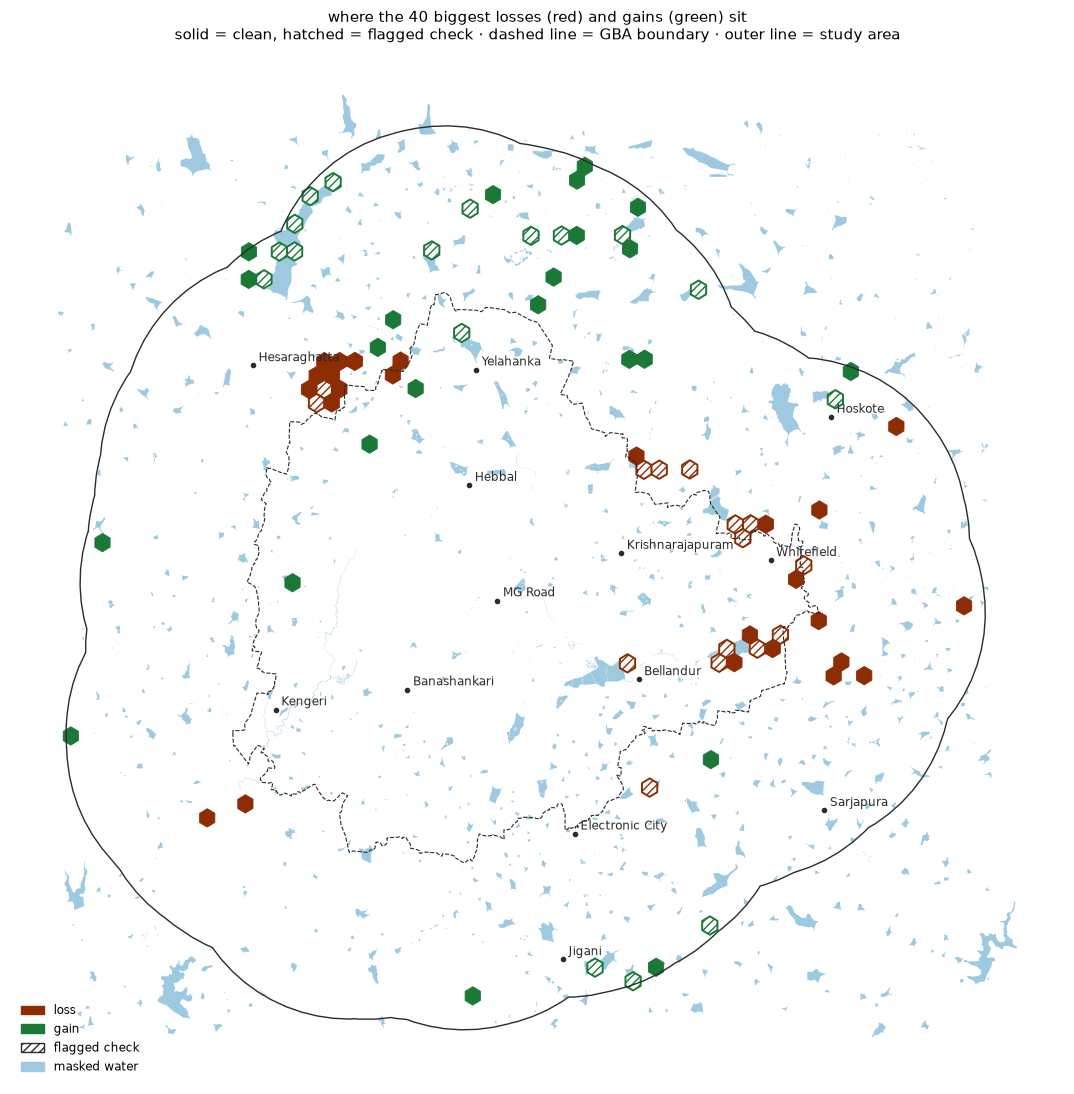

In [11]:
fig, ax = plt.subplots(figsize=(11, 11))
study.boundary.plot(ax=ax, color=INK, linewidth=1)
gba.boundary.plot(ax=ax, color=INK, linewidth=0.8, linestyle="--")
osm[osm["class"] != "wetland"].plot(ax=ax, color="#9ecae1", linewidth=0)
for idx, colour, label in ((losses, LOSS, f"{TOP} biggest losses"), (gains, GAIN, f"{TOP} biggest gains")):
    cells = grid.loc[idx]
    flagged = clean_land[idx] < CLEAN_CUTOFF
    cells[~flagged.values].plot(ax=ax, color=colour, edgecolor=colour, linewidth=0.6, label=label)
    cells[flagged.values].plot(ax=ax, facecolor="white", edgecolor=colour, linewidth=1.4, hatch="////")
for name, pt in marks:
    ax.plot(pt.x, pt.y, "o", color=INK, markersize=3)
    ax.annotate(name, (pt.x, pt.y), xytext=(4, 3), textcoords="offset points", fontsize=8.5, color=INK)
ax.set_axis_off()
ax.set_title(f"where the {TOP} biggest losses (red) and gains (green) sit\n"
             "solid = clean, hatched = flagged check · dashed line = GBA boundary · outer line = study area",
             fontsize=10.5)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=LOSS, label="loss"), Patch(color=GAIN, label="gain"),
                   Patch(facecolor="white", edgecolor=INK, hatch="////", label="flagged check"),
                   Patch(color="#9ecae1", label="masked water")], loc="lower left", fontsize=8.5, frameon=False)
plt.tight_layout(); plt.show()

**The losses land where Bangalore is visibly growing, in three clusters:**

1. **Dr. Shivaram Karanth Layout, between Hesaraghatta and Yelahanka.** 11 of the 40 losses carry
   this name, plus neighbours such as Chikka Banavara. One development accounts for about a quarter
   of the loss list. The photo check already showed farmland scraped and a road grid laid in 2024.
2. **East: Whitefield, Varthur, Panathur and the Sarjapura side.** About 15 hexes (Varthur,
   Panathur, Channasandra, Kumbena Agrahara, K Dommasandra, Mutsandra, Doddabanahalli), most of them
   just outside the GBA line.
3. **North-east of KR Puram towards Hoskote.** About 8 hexes (Aduru, Ramapura, Hirandahalli, Koralur,
   Kolathuru, Byalahalli, Gattahalli).

30 of the 40 losses sit in the fringe outside the GBA boundary, and none are in the core. That fits
section 8's stated limit (the ranking sees vegetated land losing vegetation, not the built-up core)
and the reason for the 10 km ring.

**The gains are a different kind of list, and weaker.**

- 36 of 40 are in the fringe, almost all **north**: around Hesaraghatta (the grass farm, Kakolu,
  Muthkuru), the airport-road side (Doddajala, Bande Kodigehalli, Kodagalahatti) and Jarakabandekaval.
  A few are in the south near Jigani.
- Apart from the top two, which are the known Hennagara and Hesaraghatta problems, the gains run
  0.09-0.16, against 0.10-0.23 for the losses. **17 of 40 are flagged `check`**, most of them beside a
  lake.
- **A hypothesis, not checked:** Hesaraghatta refilled from 2022 (section 3 of the photo check). The
  green cluster around it may be farms and grassland greening with more water nearby, which is crop
  and grass behaviour (gotcha 3), not new trees. Jarakabandekaval, a forest area, is the one name that
  could be real canopy gain.

**Direction check: the losses pass, the gains need work.** The loss list matches three growth areas a
resident would name, and every loss the photos have checked has been real ground. The gain list is
rural, lake-side and seasonal. It needs the same photo check, and probably the land-cover data, before
any gain is quoted.